In [31]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import cross_val_score

In [32]:
df = pd.read_csv('downloads/tesla_deliveries.csv')

In [33]:
df.head(10)

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
5,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798
6,2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961
7,2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216
8,2022,4,Europe,Model S,15145,15760,69993.86,100,563,1279.00,Interpolated (Month),13264
9,2021,3,Middle East,Model Y,7790,8208,50591.60,82,485,566.72,Interpolated (Month),3383


In [34]:
df.drop(columns=['Source_Type'], inplace=True)

In [35]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Charging_Stations       0
dtype: int64

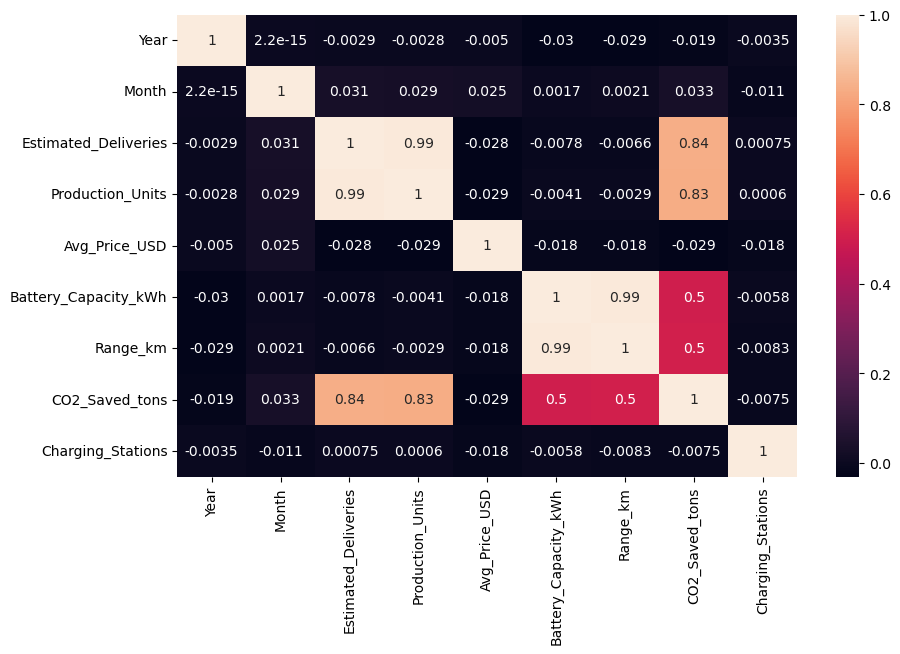

Estimated_Deliveries    1.000000
Production_Units        0.994234
CO2_Saved_tons          0.836814
Month                   0.030877
Charging_Stations       0.000753
Year                   -0.002863
Range_km               -0.006606
Battery_Capacity_kWh   -0.007765
Avg_Price_USD          -0.027546
Name: Estimated_Deliveries, dtype: float64


In [97]:
plt.figure(figsize=(10,6))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True)

plt.show()

corr = df.corr(numeric_only=True)

print(
    corr['Estimated_Deliveries']
    .sort_values(ascending=False)
)

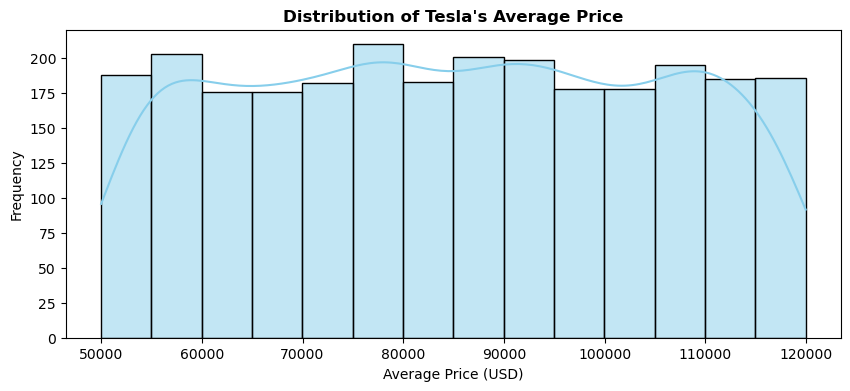

In [61]:
plt.figure(figsize=(10, 4))
sns.histplot(df['Avg_Price_USD'], kde=True, color='skyblue')
plt.title("Distribution of Tesla's Average Price", fontweight='bold')
plt.xlabel("Average Price (USD)")
plt.ylabel("Frequency")
plt.show()

<Axes: xlabel='Avg_Price_USD', ylabel='Estimated_Deliveries'>

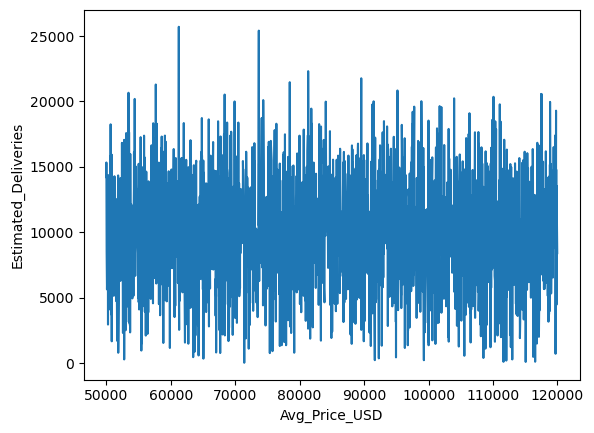

In [62]:
sns.lineplot(x='Avg_Price_USD',
             y='Estimated_Deliveries',
             data=df)

<Axes: xlabel='Production_Units', ylabel='Estimated_Deliveries'>

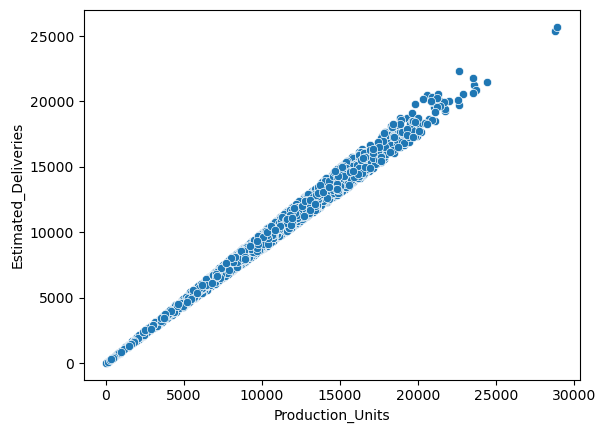

In [38]:
sns.scatterplot(
    x='Production_Units',
    y='Estimated_Deliveries',
    data=df
)

In [77]:
X = df[['Avg_Price_USD']]
y = df['Estimated_Deliveries']  

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)                                           #Splitting of data

In [79]:
num_cols = [
    'Year',
    'Month',
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Charging_Stations'
]                             #Numerical Data


cat_cols = [
    'Region',
    'Model'
]                       #Categorical Data

In [85]:
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42))
])

In [86]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', RandomForestRegressor(random_state=42))])

In [87]:
y_pred = pipeline.predict(X_test)

In [88]:
#HOLD OUT TESTING
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [89]:
#Testing
new_data = pd.DataFrame({
    'Year': [2026],
    'Month': [5],
    'Region': ['North America'],
    'Model': ['Model Y'],
    'Production_Units': [20000],
    'Avg_Price_USD': [45000],
    'Battery_Capacity_kWh': [75],
    'Range_km': [500],
    'CO2_Saved_tons': [1200],
    'Charging_Stations': [3500]
})

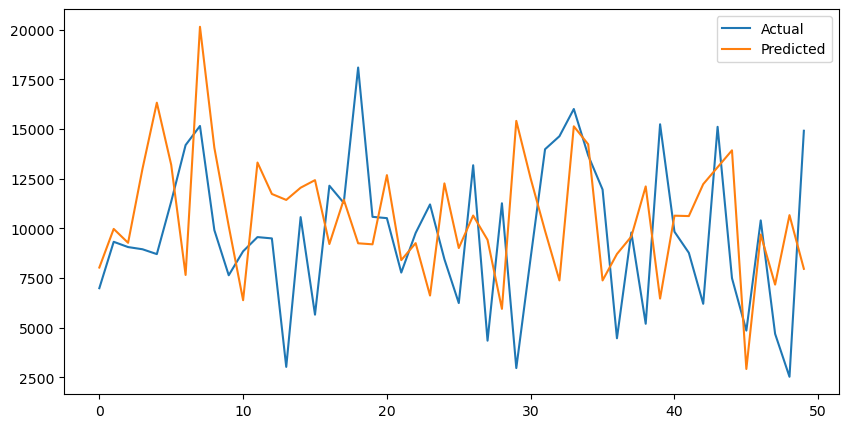

In [91]:
#VISUALIZATION TESTING
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:50], label='Actual')
plt.plot(y_pred[:50], label='Predicted')

plt.legend()
plt.show()

In [93]:
scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(scores)
print(scores.mean())

[-0.4311746  -0.58329377 -0.44667741 -0.46025214 -0.62445158]
-0.5091699005730621


In [94]:
#EVALUATION MATRICES
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 3899.3597727272727
RMSE: 4887.429551569973
R2 Score: -0.6024759086306177


In [96]:
corr = df.corr(numeric_only=True)

print(
    corr['Estimated_Deliveries']
    .sort_values(ascending=False)
)

Estimated_Deliveries    1.000000
Production_Units        0.994234
CO2_Saved_tons          0.836814
Month                   0.030877
Charging_Stations       0.000753
Year                   -0.002863
Range_km               -0.006606
Battery_Capacity_kWh   -0.007765
Avg_Price_USD          -0.027546
Name: Estimated_Deliveries, dtype: float64


In [98]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [2, 3, 5, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

In [100]:

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42))
])

In [101]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [2, 3, 5, 10, None],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [50, 100, 200]},
             scoring='r2')

In [102]:
print("Best Parameters:")
print(grid.best_params_)

print("Best CV Score:")
print(grid.best_score_)

Best Parameters:
{'model__max_depth': 2, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV Score:
-0.0030405970507696445


In [106]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

In [109]:
print("R2 :", r2_score(y_test,y_pred))             #using random forst classifier and then hypertuning  
print("MAE:", mean_absolute_error(y_test,y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test,y_pred)))

R2 : 0.0005460837813707764
MAE: 3095.647474940711
RMSE: 3859.8119192045765


In [110]:
#As the r^2 value with random forest classifier is 0ve hence trying with linear regression
from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

y_pred = lr_pipeline.predict(X_test)

from sklearn.metrics import r2_score

print(r2_score(y_test, y_pred))

0.0005460837813707764


In [116]:
from sklearn.linear_model import Ridge
param_grid = {
    'model__alpha': [0.01, 0.1, 1, 10, 100]
}

In [117]:
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

In [118]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'model__alpha': 100}
-0.0042521308489455786


In [119]:
print("R2 :", r2_score(y_test,y_pred))               
print("MAE:", mean_absolute_error(y_test,y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test,y_pred)))

R2 : 0.0005460837813707764
MAE: 3095.647474940711
RMSE: 3859.8119192045765


In [121]:
# Create date column
df['date'] = pd.to_datetime(
    df['Year'].astype(str)
    + '-'
    + df['Month'].astype(str)
)

# Monthly aggregation
monthly_df = (
    df.groupby('date')['Estimated_Deliveries']
      .sum()
      .to_frame()
)

print(monthly_df.head())

            Estimated_Deliveries
date                            
2015-01-01                183180
2015-02-01                165053
2015-03-01                184567
2015-04-01                225623
2015-05-01                184264


In [143]:
print(monthly_df.shape)

(132, 1)


In [144]:
print(monthly_df.index.min())
print(monthly_df.index.max())
print(len(monthly_df))

2015-01-01 00:00:00
2025-12-01 00:00:00
132


In [145]:
print(monthly_df.shape)
print(monthly_df.head())
print(monthly_df.tail())

(132, 1)
            Estimated_Deliveries
date                            
2015-01-01                183180
2015-02-01                165053
2015-03-01                184567
2015-04-01                225623
2015-05-01                184264
            Estimated_Deliveries
date                            
2025-08-01                214357
2025-09-01                193337
2025-10-01                178964
2025-11-01                197146
2025-12-01                209391


In [146]:
monthly_df = monthly_df.asfreq('MS')
print(monthly_df.index.freq)

print(monthly_df.index)
print(monthly_df.index.freq)

<MonthBegin>
DatetimeIndex(['2015-01-01', '2015-02-01', '2015-03-01', '2015-04-01',
               '2015-05-01', '2015-06-01', '2015-07-01', '2015-08-01',
               '2015-09-01', '2015-10-01',
               ...
               '2025-03-01', '2025-04-01', '2025-05-01', '2025-06-01',
               '2025-07-01', '2025-08-01', '2025-09-01', '2025-10-01',
               '2025-11-01', '2025-12-01'],
              dtype='datetime64[ns]', name='date', length=132, freq='MS')
<MonthBegin>


In [147]:

print("--- Data Summary ---")
print(df.info())

# 3. Create Datetime Index (Handling 'Year' and 'Month' columns)
# Note: If your variant has a 'Quarter' column, map Q1->Feb, Q2->May, etc. 
if 'Month' in df.columns:
    df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str))
elif 'Quarter' in df.columns:
    q_map = {'Q1': '03', 'Q2': '06', 'Q3': '09', 'Q4': '12'}
    df['Month'] = df['Quarter'].map(q_map)
    df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'])

--- Data Summary ---
<class 'pandas.core.frame.DataFrame'>
Index: 2640 entries, 872 to 1173
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Year                  2640 non-null   int64         
 1   Month                 2640 non-null   int64         
 2   Region                2640 non-null   object        
 3   Model                 2640 non-null   object        
 4   Estimated_Deliveries  2640 non-null   int64         
 5   Production_Units      2640 non-null   int64         
 6   Avg_Price_USD         2640 non-null   float64       
 7   Battery_Capacity_kWh  2640 non-null   int64         
 8   Range_km              2640 non-null   int64         
 9   CO2_Saved_tons        2640 non-null   float64       
 10  Charging_Stations     2640 non-null   int64         
 11  date                  2640 non-null   datetime64[ns]
 12  Date                  2640 non-null   datetime64[ns]
dtype

In [148]:
df = df.sort_values('Date')
ts_df = df.groupby('Date').agg({
    'Estimated_Deliveries': 'sum',
    'Production_Units': 'sum'
}).reset_index()

ts_df.set_index('Date', inplace=True)
print("\n--- Processed Time Series Data Head ---")
print(ts_df.head())


--- Processed Time Series Data Head ---
            Estimated_Deliveries  Production_Units
Date                                              
2015-01-01                183180            195793
2015-02-01                165053            176119
2015-03-01                184567            200151
2015-04-01                225623            241706
2015-05-01                184264            198205


In [149]:
ts_data = df.groupby('Date')['Estimated_Deliveries'].sum().asfreq('MS')

In [150]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# Split Train/Test (Keep the last 6 months for testing)
train_data = ts_data.iloc[:-6]
test_data = ts_data.iloc[-6:]


# Initialize SARIMA Model
# order=(p,d,q), seasonal_order=(P,D,Q,s). Adjust these integers based on ACF/PACF tests.
model = SARIMAX(train_data, 
                order=(1, 1, 1), 
                seasonal_order=(1, 1, 1, 12), 
                enforce_stationarity=False, 
                enforce_invertibility=False)

model_fitted = model.fit(disp=False)
print(model_fitted.summary())

# Predict over the test block period
predictions = model_fitted.predict(start=test_data.index[0], end=test_data.index[-1], dynamic=True)

# Performance Metrics Evaluation
rmse = np.sqrt(mean_squared_error(test_data, predictions))
mae = mean_absolute_error(test_data, predictions)
print(f"\n--- Test Set Metrics ---")
print(f"SARIMA RMSE: {rmse:,.2f}")
print(f"SARIMA MAE: {mae:,.2f}")



                                     SARIMAX Results                                      
Dep. Variable:               Estimated_Deliveries   No. Observations:                  126
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1131.816
Date:                            Sun, 31 May 2026   AIC                           2273.632
Time:                                    13:38:35   BIC                           2286.608
Sample:                                01-01-2015   HQIC                          2278.882
                                     - 06-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0199      0.179     -0.112      0.911      -0.370       0.330
ma.L1         -0.7062      0.095   

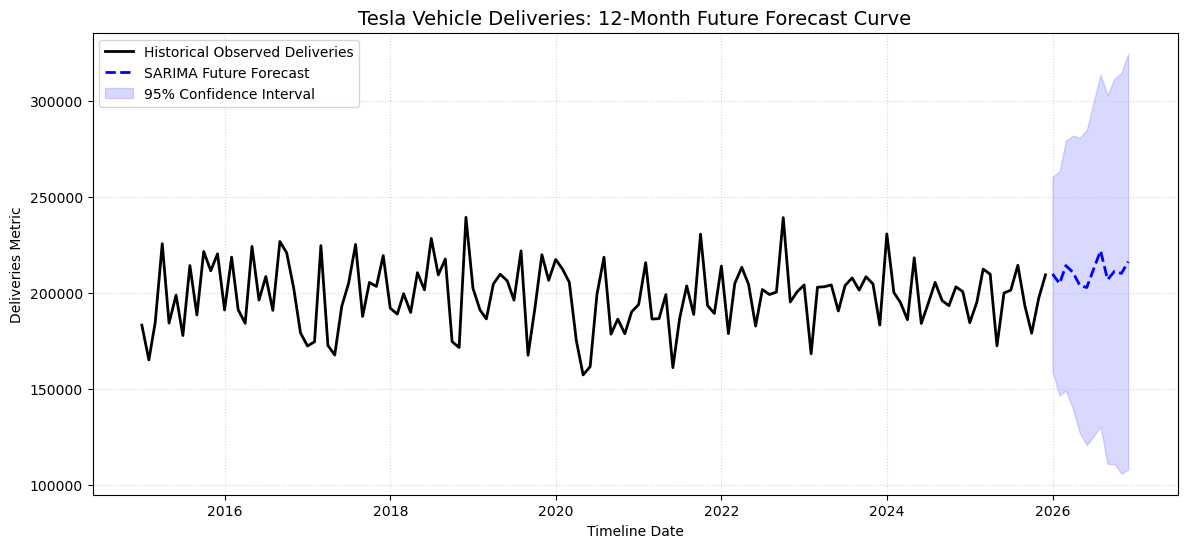


--- Next 6 Months Projected Deliveries ---
January 2026: 209,863 vehicles
February 2026: 204,851 vehicles
March 2026: 214,175 vehicles
April 2026: 210,741 vehicles
May 2026: 203,974 vehicles
June 2026: 202,763 vehicles


In [151]:
# Retrain on full historical dataset
final_model = SARIMAX(ts_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
final_fitted = final_model.fit(disp=False)

# Forecast the next 12 months ahead out-of-sample
forecast_steps = 12
forecast_output = final_fitted.get_forecast(steps=forecast_steps)

forecast_index = pd.date_range(start=ts_data.index[-1] + pd.DateOffset(months=1), periods=forecast_steps, freq='MS')
forecast_mean = forecast_output.predicted_mean
confidence_intervals = forecast_output.conf_int()

# Plot the Historical and Forecasted Deliveries together
plt.figure(figsize=(14, 6))
plt.plot(ts_data.index, ts_data, label='Historical Observed Deliveries', color='black', linewidth=2)
plt.plot(forecast_index, forecast_mean, label='SARIMA Future Forecast', color='blue', linestyle='--', linewidth=2)
plt.fill_between(forecast_index, confidence_intervals.iloc[:, 0], confidence_intervals.iloc[:, 1], color='blue', alpha=0.15, label='95% Confidence Interval')

plt.title('Tesla Vehicle Deliveries: 12-Month Future Forecast Curve', fontsize=14)
plt.xlabel('Timeline Date')
plt.ylabel('Deliveries Metric')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper left')
plt.show()

# Print specific predicted values
print("\n--- Next 6 Months Projected Deliveries ---")
for date, val in zip(forecast_index[:6], forecast_mean[:6]):
    print(f"{date.strftime('%B %Y')}: {int(val):,} vehicles")


In [153]:
rmse = np.sqrt(mean_squared_error(test_data, predictions))
mae = mean_absolute_error(test_data, predictions)

# MAPE (Mean Absolute Percentage Error) - Shows the average percentage deviation
mape = np.mean(np.abs((test_data - predictions) / test_data)) * 100
# 2. Print Performance Dashboard
print("==========================================")
print("       TIME SERIES MODEL EVALUATION       ")
print("==========================================")
print(f"Root Mean Squared Error (RMSE) : {rmse:,.2f} vehicles")
print(f"Mean Absolute Error (MAE)      : {mae:,.2f} vehicles")
print(f"Mean Absolute % Error (MAPE)   : {mape:.2f}%")
print(f"R-squared Score (R²)           : {r2:.4f}")
print("==========================================")

       TIME SERIES MODEL EVALUATION       
Root Mean Squared Error (RMSE) : 12,973.11 vehicles
Mean Absolute Error (MAE)      : 10,151.86 vehicles
Mean Absolute % Error (MAPE)   : 5.23%
R-squared Score (R²)           : -0.6025
